In [ ]:
# Credit Card Fraud Detection

## Problem Statement
Build a machine learning model to detect fraudulent credit card transactions.

In [1]:
# importing libraries required
import pandas as pd

train = pd.read_csv("fraudTrain.csv")
test = pd.read_csv("fraudTest.csv")

print(train.columns)

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='str')


In [2]:
# Dataset Description
train.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
print(train.shape)
print(test.shape)

(1296675, 23)
(555719, 23)


In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667

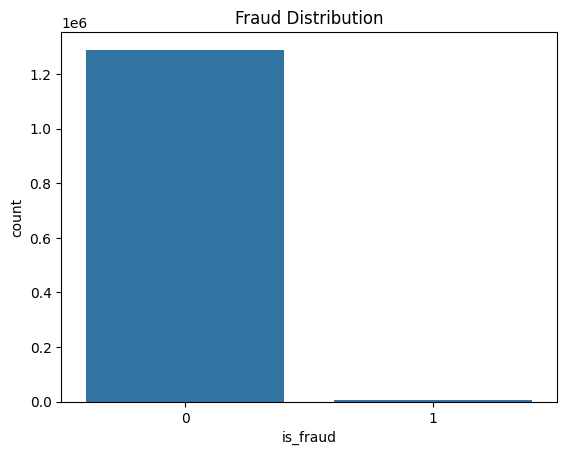

In [59]:
# Fraud Distribution Table
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='is_fraud', data=train)
plt.title("Fraud Distribution")
plt.show()

In [7]:
# Getting Age AND Hour from dob and time
train['trans_date_trans_time'] = pd.to_datetime(train['trans_date_trans_time'])
test['trans_date_trans_time'] = pd.to_datetime(test['trans_date_trans_time'])

train['dob'] = pd.to_datetime(train['dob'])
test['dob'] = pd.to_datetime(test['dob'])

In [8]:
# Feature Engineering
train['hour'] = train['trans_date_trans_time'].dt.hour
test['hour'] = test['trans_date_trans_time'].dt.hour

In [9]:
train['age'] = (
    train['trans_date_trans_time'].dt.year
    - train['dob'].dt.year
)

In [10]:
test['age'] = (
    test['trans_date_trans_time'].dt.year
    - test['dob'].dt.year
)

In [11]:
train[['hour','age']].head()

,hour,age
0,0,31
1,0,41
2,0,57
3,0,52
4,0,33


In [12]:
print("Gender :", train['gender'].nunique())
print("Category :", train['category'].nunique())
print("State :", train['state'].nunique())
print("Job :", train['job'].nunique())
print("City :", train['city'].nunique())
print("merchant :",train['merchant'].nunique())

Gender : 2
Category : 14
State : 51
Job : 494
City : 894
merchant : 693


In [13]:
# Feature Selection(Dropping useless columns )
drop_cols = [
    'Unnamed: 0',
    'first',
    'last',
    'street',
    'trans_num',
    'cc_num',
    'job',
    'city',
    'merchant',
    'dob',
    'trans_date_trans_time'
]

train = train.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)

In [14]:
train.head()

,category,amt,gender,state,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,hour,age
0,misc_net,4.97,F,NC,28654,36.0788,-81.1781,3495,1325376018,36.011293,-82.048315,0,0,31
1,grocery_pos,107.23,F,WA,99160,48.8878,-118.2105,149,1325376044,49.159047,-118.186462,0,0,41
2,entertainment,220.11,M,ID,83252,42.1808,-112.2620,4154,1325376051,43.150704,-112.154481,0,0,57
3,gas_transport,45.00,M,MT,59632,46.2306,-112.1138,1939,1325376076,47.034331,-112.561071,0,0,52
4,misc_pos,41.96,M,VA,24433,38.4207,-79.4629,99,1325376186,38.674999,-78.632459,0,0,33


In [15]:
# One-hot Encoding
train = pd.get_dummies(
    train,
    columns=['category', 'gender', 'state'],
    drop_first=True
)

test = pd.get_dummies(
    test,
    columns=['category', 'gender', 'state'],
    drop_first=True
)

In [16]:
train.shape

(1296675, 75)

In [17]:
train.head()

,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,hour,...,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY
0,4.97,28654,36.0788,-81.1781,3495,1325376018,36.011293,-82.048315,0,0,...,False,False,False,False,False,False,False,False,False,False
1,107.23,99160,48.8878,-118.2105,149,1325376044,49.159047,-118.186462,0,0,...,False,False,False,False,False,False,True,False,False,False
2,220.11,83252,42.1808,-112.2620,4154,1325376051,43.150704,-112.154481,0,0,...,False,False,False,False,False,False,False,False,False,False
3,45.00,59632,46.2306,-112.1138,1939,1325376076,47.034331,-112.561071,0,0,...,False,False,False,False,False,False,False,False,False,False
4,41.96,24433,38.4207,-79.4629,99,1325376186,38.674999,-78.632459,0,0,...,False,False,False,False,True,False,False,False,False,False


In [18]:
# Train and Test Alignment
X_train = train.drop('is_fraud', axis=1)
y_train = train['is_fraud']

X_test = test.drop('is_fraud', axis=1)
y_test = test['is_fraud']

In [19]:
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

In [20]:
#Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
# Logistic regression classifier model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [22]:
# Accuracy of logistic regression
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9247821290976195


In [52]:
# confusion matrix and classification reports
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

[[512352  41222]
 [   578   1567]]
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    553574
           1       0.04      0.73      0.07      2145

    accuracy                           0.92    555719
   macro avg       0.52      0.83      0.52    555719
weighted avg       1.00      0.92      0.96    555719



In [25]:
# Decision tree classifier
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(
    random_state=42
)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [26]:
# Decision tree model testing
y_pred_dt = dt.predict(X_test)

In [27]:
# confusion matrix and classification reports
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

[[552421   1153]
 [   398   1747]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.60      0.81      0.69      2145

    accuracy                           1.00    555719
   macro avg       0.80      0.91      0.85    555719
weighted avg       1.00      1.00      1.00    555719



In [56]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)

In [57]:
# random forest model training and testing
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [58]:
# confusion matrix and classification reports
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[553478     96]
 [   863   1282]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.93      0.60      0.73      2145

    accuracy                           1.00    555719
   macro avg       0.96      0.80      0.86    555719
weighted avg       1.00      1.00      1.00    555719



In [61]:
results = pd.DataFrame({
    'Model': [
        'Balanced Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Precision': [0.04, 0.60, 0.93],
    'Recall': [0.73, 0.81, 0.60],
    'F1 Score': [0.07, 0.69, 0.73]
})

print(results)

                          Model  Precision  Recall  F1 Score
0  Balanced Logistic Regression       0.04    0.73      0.07
1                 Decision Tree       0.60    0.81      0.69
2                 Random Forest       0.93    0.60      0.73


In [ ]:
# Conclusion
Logistic Regression achieved high accuracy but failed to identify fraudulent transactions due to class imbalance. 
Decision Tree significantly improved fraud detection with 81% recall.
Random Forest achieved the highest F1-score and precision, making it the best-performing model for this dataset.